<a href="https://colab.research.google.com/github/Tedodor423/bms-collab-notebooks/blob/main/stats/3.1_PermutationTest/3.1.11_permutation_TutorialExercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial exercises

We again use the wellbeing dataset, to practice running permutation tests.

### Set up Python libraries

As usual, run the code cell below to import the relevant Python libraries

In [1]:
# Set-up Python libraries - you need to run this but you don't need to change it
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import seaborn as sns
sns.set_theme(style='white')
import statsmodels.api as sm
import statsmodels.formula.api as smf

### Import and view the data

In [2]:
wb = pd.read_csv('https://raw.githubusercontent.com/jillxoreilly/StatsCourseBook_2024/main/data/WellbeingSample.csv')
wb

,ID_code,College,Subject,Score_preVac,Score_postVac
0,247610,Lonsdale,PPE,60,35
1,448590,Lonsdale,PPE,43,44
2,491100,Lonsdale,engineering,79,69
3,316150,Lonsdale,PPE,55,61
4,251870,Lonsdale,engineering,62,65
...,...,...,...,...,...
296,440570,Beaufort,history,75,70
297,826030,Beaufort,maths,52,49
298,856260,Beaufort,Biology,83,84
299,947060,Beaufort,engineering,62,65



### Questions

#### Test the following hypotheses:
    
1. Wellbeing scores pre- and post-vac are correlated in engineering students
2. There is a difference in the wellbeing scores of PPE students between Beaufort or Lonsdale (before the vacation)?
3. Wellbeing over all students increases across the vacation

#### Slightly harder one:

4. Wellbeing increases more across the vacation for Beaufort students than Lonsdale students

#### Detailed Instructions

In each case 1-4, you will need to decide what to do, carry it out and and write it up:

**a. Hypotheses**
* what is our null hypothesis
* what is our alternative hypothesis?

Is it a paired or unpaired test for difference of means, or a correlation test?
* therefore which `permutation_type` is needed, `samples`, `pairings` or `independent`?
        
Is it a one- or two-tailed test?
* therefore which `alternative` hypothesis type is needed, `two-sided`, `greater` or `less`?

What $\alpha$ value will you use?
* what value must $p$ be smaller than, to reject the null hypothesis?
* this is the experimenter's choice but usually 0.05 is used (sometimes 0.001 or 0.001)

**b. Test statistic and descriptive statistics**

What is your test statistic?

Report appropriate descriptive statstics and plot the data (you should choose an appropriate plot type)

**c. Carry out the permutation test**

Carry out the test. Plot the null distribution. Report the $p$-value.

**d. Report your conclusion**

Will you reject the null hypothesis, or fail to reject it? What is your cnclusion in plain English?

**e. Finally, write it up**

In each case, include a final cell in which you write the test up as if for a journal article




Engineering students pre and postvac wellbeing is correlated
correlation: 0.7812255461336072
pValue: 0.0002


<Axes: xlabel='Score_preVac', ylabel='Score_postVac'>

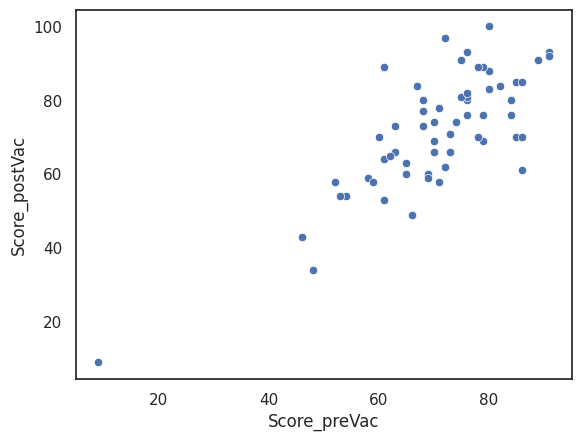

In [33]:
prevac = wb.query("Subject == 'engineering'").Score_preVac
postvac = wb.query("Subject == 'engineering'").Score_postVac

print("Engineering students pre and postvac wellbeing is correlated")
print("correlation:", prevac.corr(postvac))

test_result = stats.permutation_test(
    (prevac, postvac),
    lambda pre, post: np.corrcoef(pre, post)[0][1],
    permutation_type='pairings',
    alternative='two-sided',
    n_resamples=10000
    )
print("pValue:", round(test_result.pvalue,5))
# test_result

sns.scatterplot(data=wb.query("Subject == 'engineering'"), x="Score_preVac", y="Score_postVac")

Lonsdale and Beufort PPE students' wellbeings have a difference
difference of means: 3.9630672926447517
pValue: 0.10719


<Axes: xlabel='Subject', ylabel='Score_preVac'>

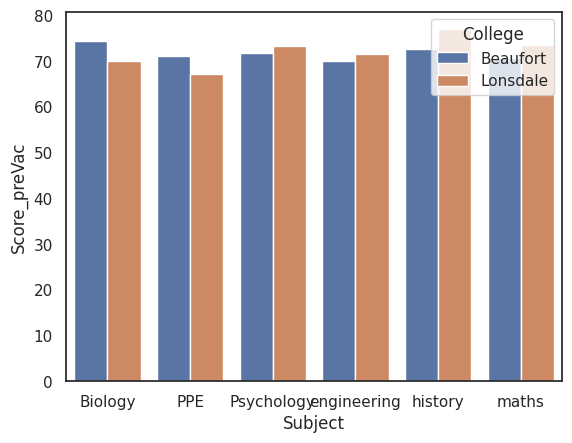

In [76]:
beaufort = wb.query("Subject == 'PPE' and College == 'Beaufort'").Score_preVac
lonsdale = wb.query("Subject == 'PPE' and College == 'Lonsdale'").Score_preVac

print("Lonsdale and Beufort PPE students' wellbeings have a difference")
print("difference of means:", beaufort.mean() - lonsdale.mean())

test_result = stats.permutation_test(
    (lonsdale, beaufort),
    lambda l, b: b.mean() - l.mean(),
    permutation_type='independent',
    alternative='two-sided',
    n_resamples=10000
    )
print("pValue:", round(test_result.pvalue,5))
# test_result
sns.barplot(data=wb.groupby(["Subject", "College"]).mean(), x="Subject", hue="College", y="Score_preVac")

Wellbeing increases after the vac
mean of differences: 2.5847176079734218
pValue: 0.0001


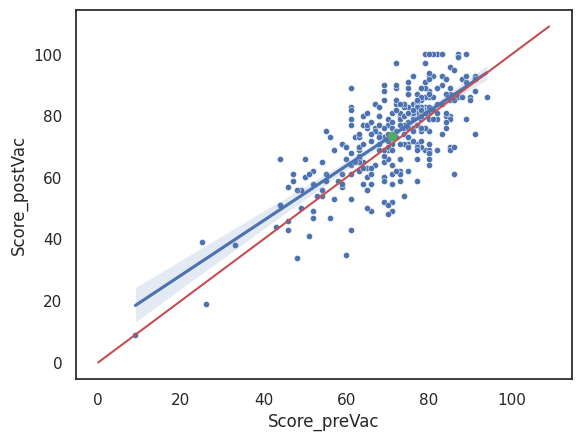

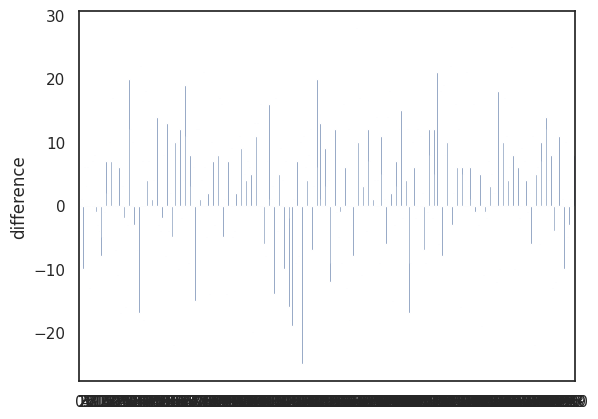

<Axes: ylabel='Count'>

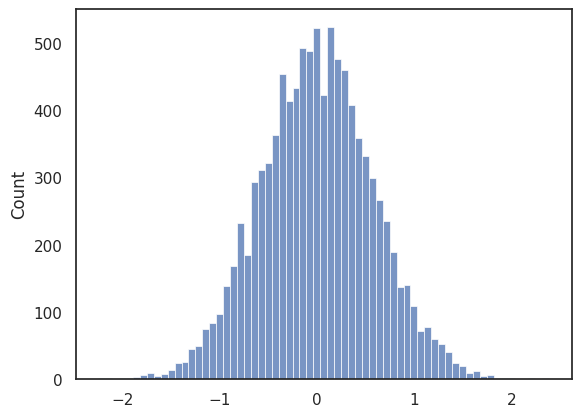

In [74]:
prevac = wb.Score_preVac
postvac = wb.Score_postVac

print("Wellbeing increases after the vac")
print("mean of differences:", (postvac - prevac).mean())

test_result = stats.permutation_test(
    (prevac, postvac),
    lambda pre, post: (post - pre).mean(),
    permutation_type='samples',
    alternative='greater',
    n_resamples=10000
    )
print("pValue:", round(test_result.pvalue,5))
# test_result

sns.scatterplot(wb, x="Score_preVac", y="Score_postVac", s=20)
sns.regplot(x=prevac, y=postvac, scatter=False)
plt.plot(range(110), range(110), 'r')
plt.plot(prevac.mean(), postvac.mean(), 'go')
plt.show()

wb["difference"] = wb.Score_postVac - wb.Score_preVac
sns.barplot(wb.difference)
plt.show()

In [81]:
beaufort = wb.query("College == 'Beaufort'")
beaufort = beaufort.Score_postVac - beaufort.Score_preVac
lonsdale = wb.query("College == 'Lonsdale'")
lonsdale = lonsdale.Score_postVac - lonsdale.Score_preVac

print("WB increases more for Beaufort than Lonsdale students")
print("difference of beaufort and lonsdale:", beaufort.mean() - lonsdale.mean())

test_result = stats.permutation_test(
    (lonsdale, beaufort),
    lambda l, b: b.mean() - l.mean(),
    permutation_type='independent',
    alternative='greater',
    n_resamples=10000
    )
print("pValue:", round(test_result.pvalue,5))

WB increases more for Beaufort than Lonsdale students
difference of beaufort and lonsdale: 0.8040571480904846
pValue: 0.23968
